# Detección de Edificios Terran en StarCraft II con YOLO
### Lectura estratégica en tiempo real para el *scouting*

En *StarCraft II*, en los primeros minutos se envía una unidad exploradora a la base
enemiga. Los edificios visibles revelan la estrategia completa del rival: qué unidades
produce, el momento del ataque y la composición de su ejército. El jugador tiene
~30 segundos para identificar todos los edificios, retenerlos mentalmente y decidir.

Este proceso se automatiza con visión por computadora: entrenamos un detector **YOLO**
de edificios Terran y, sobre cada detección, entregamos una **lectura estratégica**
(no solo la caja en pantalla).

> Ejemplo: detectar un *Starport* en el minuto 4 = predecir un ataque aéreo = cambiar
> el plan de juego completo.

Se consideran además: edificios **en construcción** (silueta distinta al terminado),
**desbalance de clases** (el Command Center aparece en toda partida, el Armory casi
nunca) y **variación de mapas** (el terreno cambia, el modelo 3D del edificio no).

## Instalar librerías necesarias

In [1]:
# Documentación Ultralytics: https://docs.ultralytics.com/
# En local: instalar primero PyTorch con CUDA para usar la GPU (https://pytorch.org/get-started/locally/)
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126
!pip install ultralytics gdown


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Descargar el conjunto de datos

Dataset **SC2-Scouting** (etiquetado en Roboflow, formato YOLO) con carpetas
`train/`, `valid/`, `test/` (cada una con `images/` y `labels/`) más el `data.yaml`.

Clases (7): `Armory`, `Barracks`, `Command_center`, `Engineering_bay`, `Factory`,
`Refinery`, `Starport`.

In [ ]:
# Opción 1: descargar la carpeta del dataset directo desde Google Drive
!gdown --folder "https://drive.google.com/drive/folders/1W8wXHMODBA1pAG5TYcGmCQXRt73HRwuw?usp=sharing" -O SC2_Scouting
# Opción 2: si Drive limita la descarga, descargar el zip manualmente y descomprimirlo:
# !unzip "SC2_Scouting.zip" -d SC2_Scouting

In [2]:
# El data.yaml exportado por Roboflow trae rutas relativas (../train/images);
# lo reescribimos con las rutas absolutas de este computador
import os

base = os.path.abspath("SC2_Scouting").replace("\\", "/")
yaml_txt = f"""train: {base}/train/images
val: {base}/valid/images
test: {base}/test/images

nc: 7
names: ['Armory', 'Barracks', 'Command_center', 'Engineering_bay', 'Factory', 'Refinery', 'Starport']
"""
with open("SC2_Scouting/data.yaml", "w") as f:
    f.write(yaml_txt)
print(yaml_txt)

train: c:/Users/Lenovo/Documents/vision por computadora/SC2_Scouting/train/images
val: c:/Users/Lenovo/Documents/vision por computadora/SC2_Scouting/valid/images
test: c:/Users/Lenovo/Documents/vision por computadora/SC2_Scouting/test/images

nc: 7
names: ['Armory', 'Barracks', 'Command_center', 'Engineering_bay', 'Factory', 'Refinery', 'Starport']



## Librerías a utilizar

In [1]:
%matplotlib inline

from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import cv2 as cv
import torch
import os

## Entrenar modelo

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU disponible. Usando:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("No hay GPU disponible. Usando CPU.")

GPU disponible. Usando: NVIDIA GeForce RTX 4070 Laptop GPU


In [5]:
# Cargar un modelo YOLO26s preentrenado (se descarga automáticamente la primera vez)
model = YOLO("yolo26s.pt")

In [6]:
model.info()

YOLO26s summary: 260 layers, 10,009,784 parameters, 0 gradients, 22.8 GFLOPs


(260, 10009784, 0, 22.838476800000002)

### Manejo del desbalance de clases y la variación de mapas

Como el *Command Center*, la *Refinery* o las *Barracks* aparecen en casi toda partida
y el *Armory* o el *Starport* son menos frecuentes, se ajustan parámetros del entrenamiento:

- **`copy_paste`, `mosaic`, `mixup`:** *data augmentation* que multiplica la aparición de
  clases minoritarias y combina fondos (ayuda también con la variación de mapas).
- **`cls`:** mayor peso de la pérdida de clasificación (no confundir edificios parecidos).
- **`hsv_*`, `scale`, `fliplr`:** robustez ante distintos terrenos y distancias del scout.
- **`flipud=0.0`:** los edificios nunca aparecen "boca abajo", no se voltea en vertical.

> Nota: en versiones antiguas se usaba focal loss vía `fl_gamma`; ese argumento fue
> removido en Ultralytics reciente, por eso queda comentado.

In [7]:
# Cargar un modelo YOLO26s preentrenado (nunca desde cero: con un dataset pequeño
# es imprescindible partir de los pesos .pt preentrenados)
model = YOLO("yolo26s.pt")

train_results = model.train(
    data="SC2_Scouting/data.yaml",  # Ruta al archivo de configuración del conjunto de datos
    epochs=150,         # Límite máximo de épocas (YOLO26 converge rápido con su optimizador MuSGD)
    imgsz=640,          # Tamaño de las imágenes durante el entrenamiento
    device=0,           # GPU local (RTX 4070)
    batch=8,            # Lote acotado para los 8 GB de VRAM (subir a 16 si no se llena)
    patience=30,        # Early stopping: corta si la validación no mejora en 30 épocas (evita overfitting)
    # fl_gamma=1.5,     # Focal loss: argumento removido en Ultralytics reciente (rompería el train)
    cls=0.7,            # Ganancia de la pérdida de clasificación
    mosaic=1.0,         # Augmentation: combina 4 imágenes
    mixup=0.15,         # Augmentation: mezcla de imágenes
    copy_paste=0.3,     # Augmentation: pega instancias (clases minoritarias)
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,   # Variación de color/terreno (mapas)
    scale=0.5,          # Edificios vistos a distintas distancias
    fliplr=0.5,         # Volteo horizontal
    flipud=0.0,         # NO voltear en vertical (edificios siempre de pie)
)

Ultralytics 8.4.90  Python-3.14.4 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.7, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=SC2_Scouting/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

## Evaluar métricas

- **Box (Precision):** Mide la precisión de las cajas delimitadoras detectadas.
- **Recall:** Mide la capacidad del modelo para encontrar todas las instancias de un objeto.
- **mAP50:** Precisión promedio por clase con un umbral de IoU de 0.50.
- **mAP50-95:** Métrica más estricta (promedio sobre IoU 0.50 a 0.95).

En este problema importa especialmente el **recall de las clases raras**: es peor no
detectar un Starport (y comerse el ataque aéreo) que tener algún falso positivo.

In [3]:
# Cargar el mejor modelo
model = YOLO("runs/detect/train/weights/best.pt")

# Evaluar el modelo
metrics = model.val(
    device=0,
    plots=True,
    visualize=True
)

Ultralytics 8.4.90  Python-3.14.4 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO26s summary (fused): 122 layers, 9,467,889 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1457.796.1 MB/s, size: 3283.4 KB)
val: Scanning C:\Users\Lenovo\Documents\vision por computadora\SC2_Scouting\valid\labels.cache... 38 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 38/38 14.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.1it/s 2.7s1.2ss
                   all         38        197      0.926      0.932      0.974      0.743
                Armory          8         12      0.983          1      0.995      0.824
              Barracks         25         53      0.923          1      0.979      0.683
        Command_center         31         34      0.969          1      0.982      0.767
       Engineering_bay         17         24      0.954      0.863  

## Visualizar algunas validaciones

- **Ground Truth (Etiqueta Real):** cajas y clases que indican dónde y qué objetos deberían detectarse.
- **True Positives:** predicciones que coinciden correctamente con una etiqueta real.
- **False Positives:** predicciones que no coinciden con ninguna etiqueta real.
- **False Negatives:** objetos reales que el modelo no detectó.

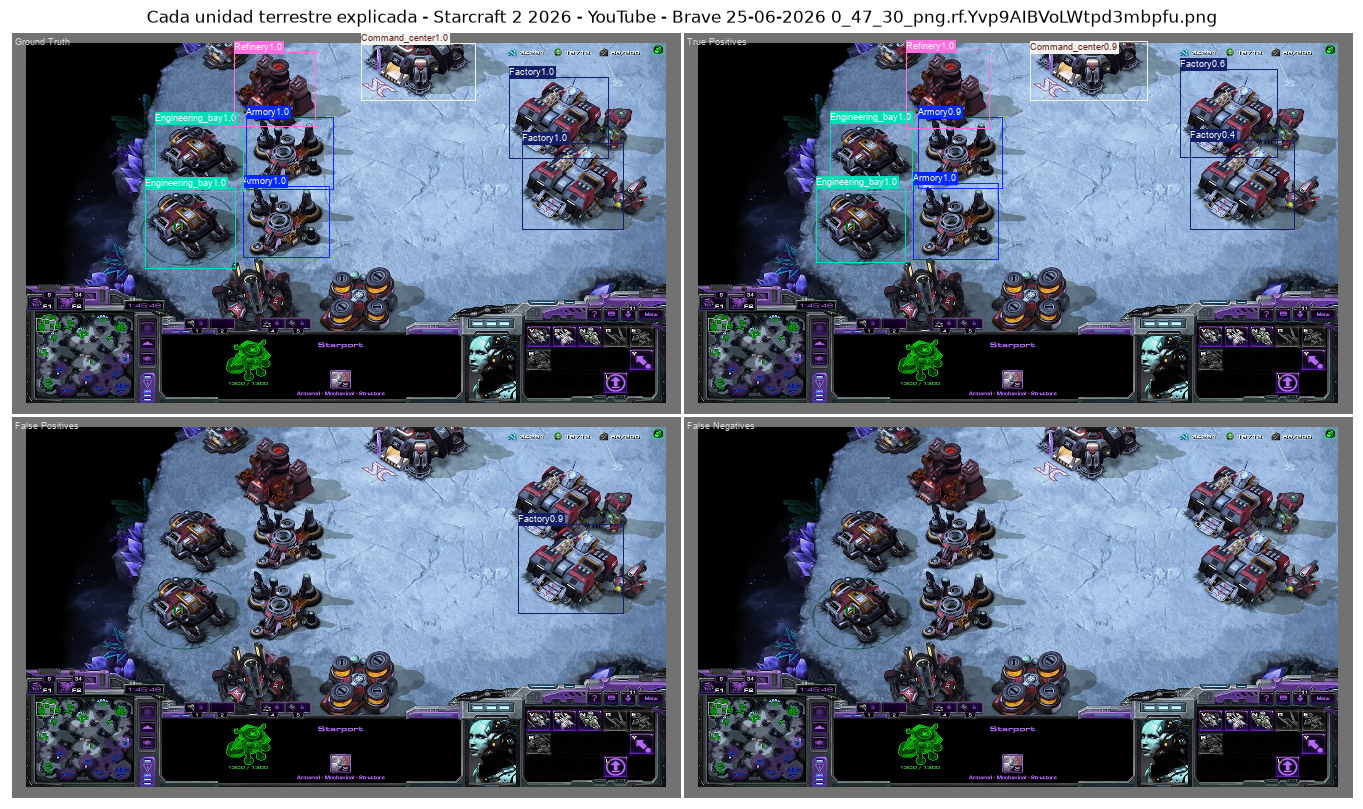

In [4]:
# Carpeta con las visualizaciones generadas por model.val() (los nombres de archivo
# vienen de Roboflow, por eso tomamos una de la carpeta en vez de escribirlo a mano)
vis_dir = 'runs/detect/val/visualizations'
visualizaciones = sorted(os.listdir(vis_dir))
img_path = os.path.join(vis_dir, visualizaciones[0])  # cambiar el índice para ver otra

# Verificar si el archivo de imagen existe
if os.path.exists(img_path):
    img = mpimg.imread(img_path)

    # Mostrar la imagen sin bordes blancos
    fig, ax = plt.subplots(figsize=(img.shape[1]/100, img.shape[0]/100), dpi=100) # Ajustar tamaño de figura
    ax.imshow(img)
    ax.set_title(os.path.basename(img_path)) # Usar el nombre del archivo como título
    ax.axis('off') # Ocultar ejes

    # Eliminar el espacio en blanco alrededor de la imagen
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    plt.margins(0,0)
    ax.xaxis.set_major_locator(plt.NullLocator())
    ax.yaxis.set_major_locator(plt.NullLocator())

    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {img_path}")

## Evaluación gráfico F1-Score/Confidence

El F1-Score combina la **Precisión** y el **Recall**:

$$ \text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} $$

Un valor alto indica buena precisión (pocas falsas detecciones) y buen recall
(encuentra la mayoría de los objetos).

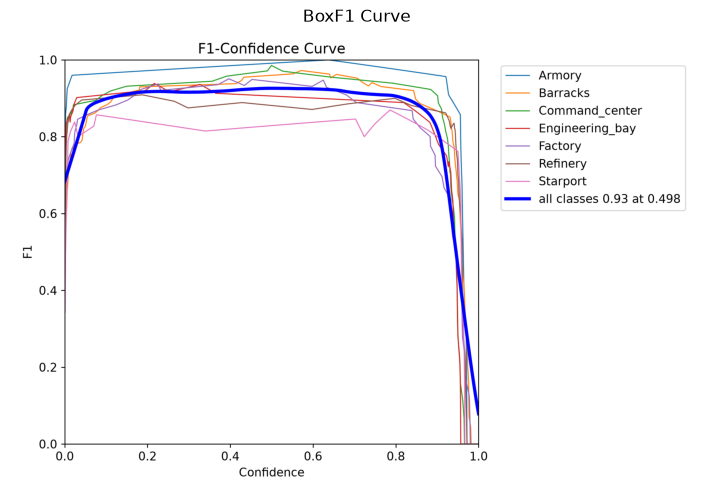

In [5]:
image_path = 'runs/detect/val/BoxF1_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('BoxF1 Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

## Evaluación gráfico Precision/Recall

Muestra la relación entre precisión y recall a distintos umbrales de confianza.

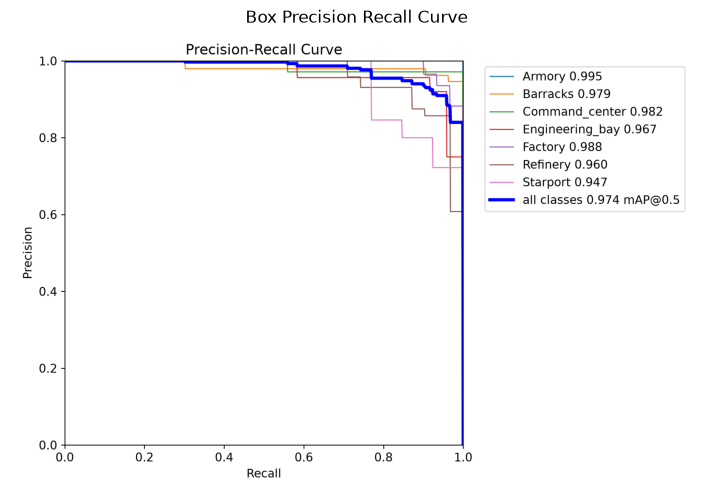

In [6]:
image_path = 'runs/detect/val/BoxPR_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('Box Precision Recall Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

## Evaluación gráfico Precision/Confidence

Muestra cómo cambia la precisión del modelo según el umbral de confianza usado.

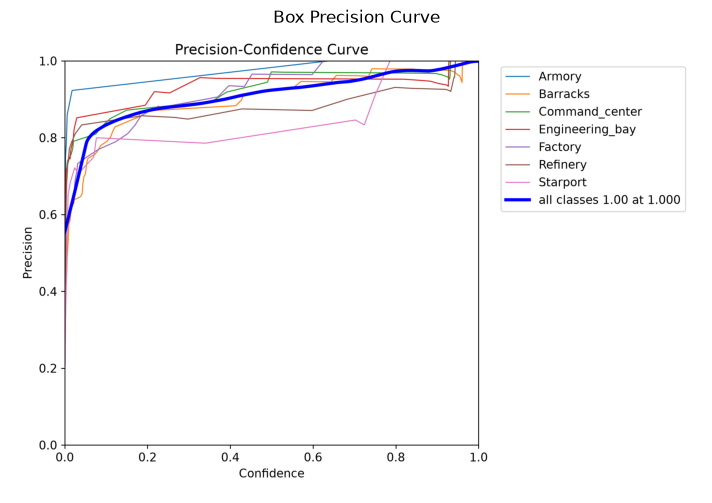

In [7]:
image_path = 'runs/detect/val/BoxP_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('Box Precision Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

## Evaluación gráfico Recall/Confidence

Muestra cómo varía el recall del modelo según el umbral de confianza aplicado.

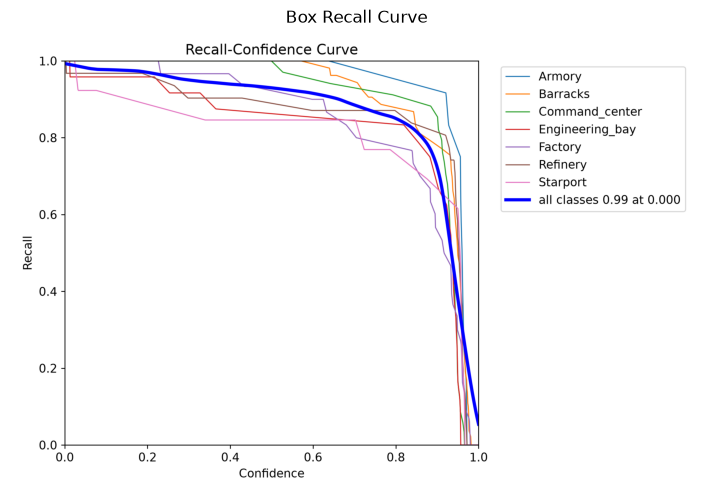

In [8]:
image_path = 'runs/detect/val/BoxR_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('Box Recall Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

## Matriz de Confusión

- **Diagonal Principal:** número de predicciones correctas por clase (mientras más alto, mejor).
- **Fuera de la Diagonal:** errores de clasificación (el modelo confundió una clase con otra).

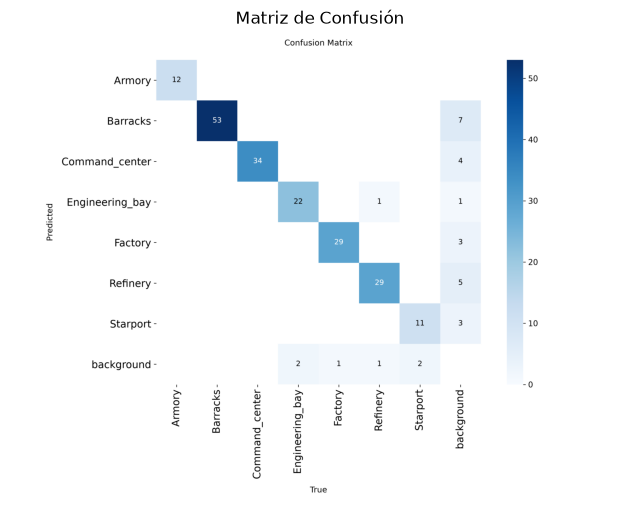

In [9]:
image_path = 'runs/detect/val/confusion_matrix.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title('Matriz de Confusión')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

## Matriz de Confusión Normalizada

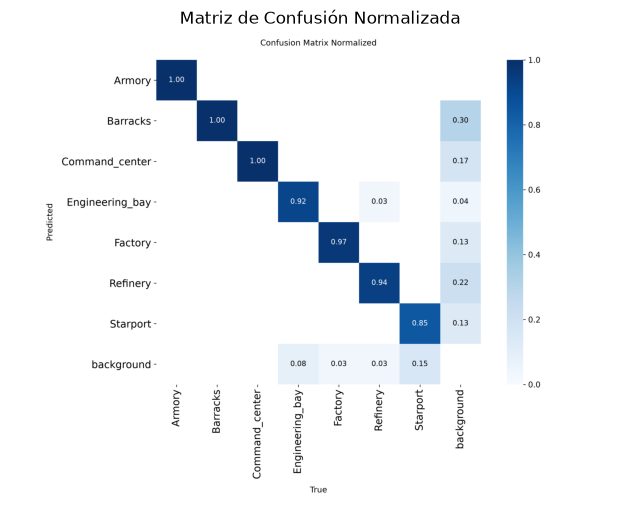

In [10]:
image_path = 'runs/detect/val/confusion_matrix_normalized.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title('Matriz de Confusión Normalizada')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

## Predicciones del modelo sobre datos nuevos

Probamos el modelo sobre una **imagen nueva que no pertenece al dataset**: un frame del
video de scouting (`scout_frame.jpg`), el explorador observando la base enemiga. El dibujo
de las cajas, etiquetas y confianza se hace **exclusivamente con OpenCV** (función
`dibujar_detecciones`, sin usar el `r.plot()` de Ultralytics).

In [6]:
# --- Dibujo de detecciones SOLO con OpenCV (cv2) ---
# En este avance el dibujo de cajas, etiquetas y confianza se hace exclusivamente con
# OpenCV (cv2.rectangle + cv2.putText), sin usar el r.plot() de Ultralytics.
def dibujar_detecciones(img, r, model, conf_min=0.35):
    """Dibuja la caja, el nombre de la clase y la confianza de cada detección con OpenCV."""
    for box in r.boxes:
        conf = float(box.conf)
        if conf < conf_min:
            continue
        x1, y1, x2, y2 = map(int, box.xyxy[0])        # coordenadas de la caja
        etiqueta = f"{model.names[int(box.cls)]} {conf:.2f}"

        # Caja delimitadora (verde)
        cv.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Fondo + texto de la etiqueta con la confianza (para que se lea sobre la caja)
        (tw, th), _ = cv.getTextSize(etiqueta, cv.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        cv.rectangle(img, (x1, y1 - th - 8), (x1 + tw + 4, y1), (0, 255, 0), -1)
        cv.putText(img, etiqueta, (x1 + 2, y1 - 5), cv.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2, cv.LINE_AA)
    return img


image 1/1 c:\Users\Lenovo\Documents\vision por computadora\scout_frame.jpg: 384x640 1 Barracks, 1 Command_center, 2 Refinerys, 57.5ms
Speed: 1.3ms preprocess, 57.5ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)
Bounding Box: tensor([[ 801.0184,   24.0973, 1048.8833,  269.7861]], device='cuda:0'), Confidence: tensor([0.9359], device='cuda:0'), Class: Refinery
Bounding Box: tensor([[460.2426, 280.3296, 832.8114, 634.7850]], device='cuda:0'), Confidence: tensor([0.9139], device='cuda:0'), Class: Command_center
Bounding Box: tensor([[ 978.8334,  178.3610, 1230.8789,  437.8242]], device='cuda:0'), Confidence: tensor([0.9013], device='cuda:0'), Class: Refinery
Bounding Box: tensor([[513.7513, 611.9677, 751.8481, 853.0045]], device='cuda:0'), Confidence: tensor([0.4873], device='cuda:0'), Class: Barracks


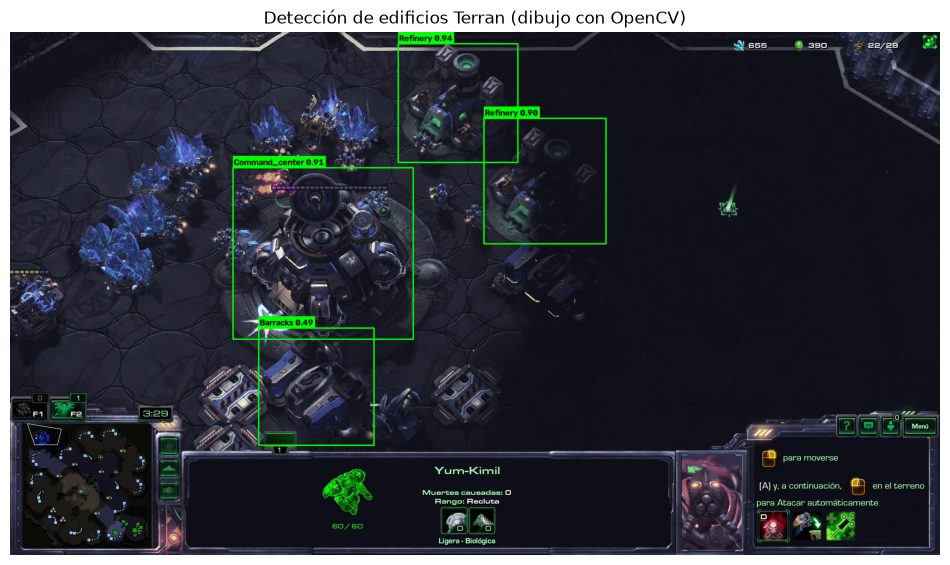

In [7]:
# Cargar el mejor modelo entrenado
model = YOLO('runs/detect/train/weights/best.pt')

# Imagen NUEVA de prueba: un frame del video de scouting (NO pertenece al dataset).
# scout_frame.jpg = el explorador viendo la base enemiga (Command Center, Barracks, Refinery).
image_path = 'scout_frame.jpg'

# Realizar la detección
results = model(image_path)

# Mostrar las coordenadas, la confianza y la clase de cada detección
for r in results:
    for box in r.boxes:
        # box.xyxy = coordenadas [x1, y1, x2, y2]; box.conf = confianza; box.cls = clase
        print(f"Bounding Box: {box.xyxy}, Confidence: {box.conf}, Class: {model.names[int(box.cls)]}")

    # Dibujo EXCLUSIVAMENTE con OpenCV (cajas + etiqueta + confianza)
    im_array = dibujar_detecciones(cv.imread(image_path), r, model)

    # Convertir de BGR (OpenCV) a RGB para mostrar con matplotlib
    im_rgb = cv.cvtColor(im_array, cv.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 7))
    plt.imshow(im_rgb)
    plt.axis('off')
    plt.title('Detección de edificios Terran (dibujo con OpenCV)')
    plt.show()

    # Guardar el resultado
    cv.imwrite('resultado_imagen.jpg', im_array)

## Lectura estratégica de cada edificio

Hasta aquí YOLO entrega cajas. Ahora traducimos cada edificio detectado en una
**decisión estratégica**. Usamos un diccionario `INFO_ESTRATEGICA` (igual que el
diccionario de clases del notebook de poses) donde, para cada edificio, se indica qué
produce, la amenaza, el momento y la respuesta recomendada.

In [8]:
# Información estratégica por edificio Terran.
# Clases del data.yaml actual (7): Armory, Barracks, Command_center, Engineering_bay,
# Factory, Refinery, Starport — lectura_estrategica() las normaliza a minúsculas con espacios.
# Se dejan también los demás edificios Terran por si el dataset se amplía después.
INFO_ESTRATEGICA = {
    "command center":     ("SCV y economía",        "El rival juega macro/largo",          "Min 0-5",  "Si expande temprano, castígalo con presión"),
    "orbital command":    ("MULEs y escaneo",        "Economía fuerte + detección (anti-cloak)", "Min 2-4",  "Tu invisibilidad pierde valor, pueden escanear"),
    "planetary fortress": ("Defensa pesada + economía","Turtle / defensa de expansiones",   "Min 6+",   "Evita asaltos frontales, usa aire o cerco"),
    "supply depot":       ("Suministro",             "Wall-in / control de rampa",          "Min 0-2",  "Cuenta cuántos para estimar su población"),
    "refinery":           ("Recolección de gas",     "Sin gas = all-in barato; doble gas = tech rush", "Min 1-3", "Sin gas prepárate para all-in temprano"),
    "barracks":           ("Marines, Marauders, Reapers","Infantería (bio); varios = timing push", "Min 1-4", "Prepara defensa anti-bio y cuenta los Barracks"),
    "engineering bay":    ("Upgrades de infantería y Turrets","+1 timing attack o turtle",   "Min 2-5",  "Iguala upgrades, cuidado con el +1 timing"),
    "bunker":             ("Defensa estática",       "Bunker rush (all-in) o contención",   "Min 1-3",  "Si está avanzado = all-in: defiende y mata SCVs"),
    "missile turret":     ("Defensa antiaérea + detección","Espera ataques aéreos / cloak", "Min 3+",   "Tu juego aéreo/invisible es esperado"),
    "sensor tower":       ("Radar de área",          "Sabrá cuándo te acercas",             "Min 4+",   "Evita timings sorpresa, juega multi-frente"),
    "factory":            ("Hellions, Tanks, Cyclone","Hellion harass o transición a mech", "Min 3-6",  "Protege a tus trabajadores de Hellions"),
    "ghost academy":      ("Ghosts (EMP, snipe, nuke)","EMP anti-energía/escudos, snipe, nuke", "Min 6+", "Dispersa unidades caras, cuidado con EMP"),
    "starport":           ("Medivac, Banshee, Liberator","ATAQUE AÉREO (Banshee puede ser cloak)", "Min 4-6", "Construye antiaéreo YA y consigue DETECCIÓN"),
    "armory":             ("Upgrades de mech y aire", "Confirma mech/aire pesado con upgrades","Min 6+",  "Prepárate para composición pesada late-game"),
    "fusion core":        ("Battlecruiser",          "BATTLECRUISERS: aire pesado late-game","Min 8+",  "Acumula antiaéreo de alto DPS o presiona ya"),
}

# Edificios de prioridad ALTA: disparan alerta inmediata en el scouting
PRIORIDAD_ALTA = ["refinery", "barracks", "bunker", "factory", "starport", "fusion core"]
print("Base de conocimiento cargada:", len(INFO_ESTRATEGICA), "edificios.")

Base de conocimiento cargada: 15 edificios.


In [9]:
def lectura_estrategica(results, model, conf_min=0.35):
    """Recorre las detecciones de YOLO y entrega un reporte estratégico del scouting."""
    conteo = {}            # cuántos hay de cada edificio
    construccion = {}      # cuántos están en construcción
    confianza = {}         # confianza máxima detectada por edificio (fiabilidad de la lectura)

    print("=" * 60)
    print("REPORTE DE SCOUTING - LECTURA ESTRATÉGICA")
    print("=" * 60)

    for r in results:
        for box in r.boxes:
            if float(box.conf) < conf_min:
                continue
            nombre = model.names[int(box.cls)].lower()

            # Detectar si el edificio está en construcción (silueta distinta)
            en_construccion = ("constr" in nombre) or ("const" in nombre) or ("building" in nombre)

            # Nombre base del edificio (sin el estado de construcción)
            clave = nombre.replace("_construction", "").replace("_const", "")
            clave = clave.replace("_", " ").replace("-", " ").strip()

            conteo[clave] = conteo.get(clave, 0) + 1
            confianza[clave] = max(confianza.get(clave, 0), float(box.conf))
            if en_construccion:
                construccion[clave] = construccion.get(clave, 0) + 1

    if not conteo:
        print("No se detectaron edificios (revisa conf_min o la base aún sin explorar).")
        return

    # Reporte por edificio
    for clave, n in conteo.items():
        wip = construccion.get(clave, 0)
        info = INFO_ESTRATEGICA.get(clave)
        extra = f" ({wip} en construcción)" if wip else ""
        # La confianza de la detección es también la fiabilidad de esta lectura estratégica
        print(f"\n[{clave.title()}] x{n}  (confianza {confianza[clave]:.2f} = {confianza[clave]*100:.0f}%){extra}")
        if info:
            produce, amenaza, timing, respuesta = info
            print(f"   Produce  : {produce}")
            print(f"   Amenaza  : {amenaza}")
            print(f"   Timing   : {timing}")
            print(f"   Respuesta: {respuesta}")
            if clave in PRIORIDAD_ALTA:
                print("   >>> PRIORIDAD ALTA <<<")
            if wip:
                print("   (En construcción: amenaza inminente pero aún no operativa)")
        else:
            print("   (sin información estratégica registrada)")

    # Alertas por combinaciones de edificios
    print("\n" + "-" * 60)
    print("ALERTAS POR COMBINACIÓN:")
    if "starport" in conteo:
        print("   ! Starport detectado: viene ataque aéreo, consigue antiaéreo + detección")
    if conteo.get("barracks", 0) >= 3:
        print(f"   ! {conteo['barracks']} Barracks: posible timing push / all-in de bio")
    if "factory" in conteo and "armory" in conteo:
        print("   ! Factory + Armory: transición a mech pesado (Thor/Tanques)")
    if "fusion core" in conteo:
        print("   ! Fusion Core: vienen Battlecruisers, antiaéreo pesado o presiona ya")
    if conteo.get("refinery", 0) == 0 and conteo.get("barracks", 0) >= 1:
        print("   ! Barracks sin gas: posible all-in barato de Marines / proxy")
    print("=" * 60)

Aplicamos la lectura estratégica sobre las detecciones de la imagen anterior:


image 1/1 c:\Users\Lenovo\Documents\vision por computadora\scout_frame.jpg: 384x640 1 Barracks, 1 Command_center, 2 Refinerys, 7.7ms
Speed: 1.3ms preprocess, 7.7ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)


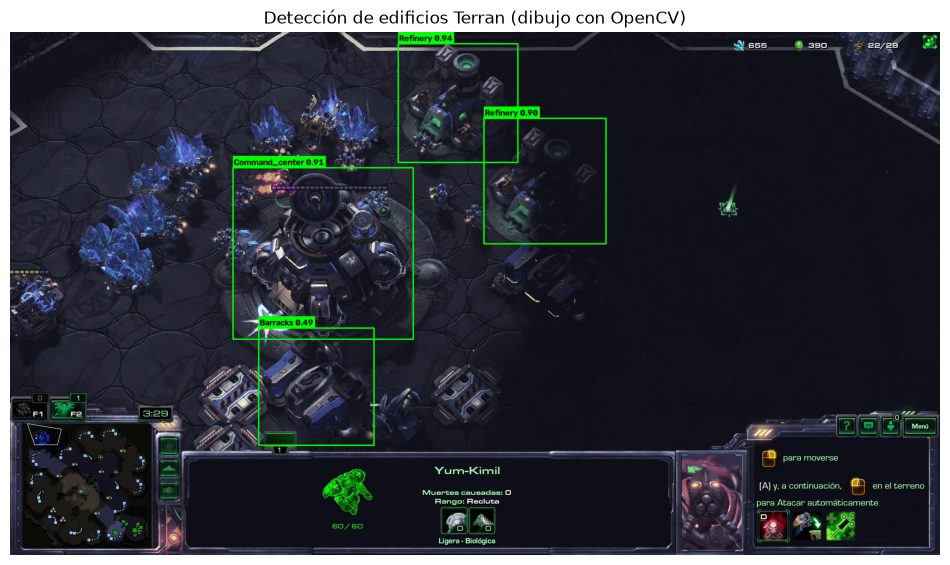

REPORTE DE SCOUTING - LECTURA ESTRATÉGICA

[Refinery] x2  (confianza 0.94 = 94%)
   Produce  : Recolección de gas
   Amenaza  : Sin gas = all-in barato; doble gas = tech rush
   Timing   : Min 1-3
   Respuesta: Sin gas prepárate para all-in temprano
   >>> PRIORIDAD ALTA <<<

[Command Center] x1  (confianza 0.91 = 91%)
   Produce  : SCV y economía
   Amenaza  : El rival juega macro/largo
   Timing   : Min 0-5
   Respuesta: Si expande temprano, castígalo con presión

[Barracks] x1  (confianza 0.49 = 49%)
   Produce  : Marines, Marauders, Reapers
   Amenaza  : Infantería (bio); varios = timing push
   Timing   : Min 1-4
   Respuesta: Prepara defensa anti-bio y cuenta los Barracks
   >>> PRIORIDAD ALTA <<<

------------------------------------------------------------
ALERTAS POR COMBINACIÓN:


In [10]:
# Aplicar la lectura estratégica sobre el mismo frame de scouting
model = YOLO('runs/detect/train/weights/best.pt')
results = model(image_path, conf=0.35)

# Dibujar con OpenCV (cajas + confianza) y mostrar
for r in results:
    im_rgb = cv.cvtColor(dibujar_detecciones(cv.imread(image_path), r, model), cv.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 7))
    plt.imshow(im_rgb)
    plt.axis('off')
    plt.title('Detección de edificios Terran (dibujo con OpenCV)')
    plt.show()

# Entregar la lectura estratégica (incluye la confianza como fiabilidad de cada lectura)
lectura_estrategica(results, model, conf_min=0.35)

## Lectura estratégica en tiempo real (video)

Procesamos un clip del *scouting* frame a frame. Cada vez que aparece un edificio nuevo,
se actualiza la memoria del scout y se vuelve a generar la lectura estratégica (igual que
el asistente que tendría un jugador mientras explora).

In [11]:
# Clips de scouting grabados del juego (el explorador llegando a la base enemiga).
# Si el repo ya trae los .mp4 en videos_scout/ no se descarga nada; si no, se baja el
# zip desde Drive. Usamos zipfile de Python para descomprimir igual en Windows y Colab.
import zipfile, glob

videos = sorted(glob.glob("videos_scout/*.mp4"))
if not videos:
    zip_videos = "StarCraft II 2026-07-13 23-07-11.zip"
    if not os.path.exists(zip_videos):
        !gdown "https://drive.google.com/uc?id=1bUIooaaQ8pSQ3mx4JjwAhcVyvJwArbwN" -O "{zip_videos}"
    with zipfile.ZipFile(zip_videos) as z:
        z.extractall("videos_scout")
    videos = sorted(glob.glob("videos_scout/*.mp4"))

# Clips disponibles (en la celda siguiente se elige cuál probar por su índice)
for i, v in enumerate(videos):
    print(i, "-", os.path.basename(v))

0 - StarCraft II 2026-07-13 20-56-37.mp4
1 - StarCraft II 2026-07-13 20-57-22.mp4
2 - StarCraft II 2026-07-13 21-00-06.mp4
3 - StarCraft II 2026-07-13 23-07-11.mp4
4 - StarCraft II 2026-07-13 23-10-21.mp4


In [12]:
model = YOLO('runs/detect/train/weights/best.pt')

# Por defecto el clip de scouting (el explorador llegando a la base enemiga, ~16 s).
# Cambia el índice si quieres probar otro de la lista de arriba.
video_in  = next((v for v in videos if "23-07-11" in v), videos[4])
# video_in = videos[0]   # <- o elige manualmente por índice (0, 1, 2, ...)
video_out = 'scout_anotado.mp4'
print("Reproduciendo:", os.path.basename(video_in))
print("Se abre una ventana con el video. Presiona 'q' sobre ella para cortar.")

cap = cv.VideoCapture(video_in)
fps = cap.get(cv.CAP_PROP_FPS) or 30
w = int(cap.get(cv.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv.CAP_PROP_FRAME_HEIGHT))
out = cv.VideoWriter(video_out, cv.VideoWriter_fourcc(*'mp4v'), fps, (w, h))

# Ventana redimensionable para que no salga más grande que la pantalla
cv.namedWindow("Scouting en vivo - SC2", cv.WINDOW_NORMAL)
cv.resizeWindow("Scouting en vivo - SC2", 1280, 720)

edificios_vistos = set()
frame_idx = 0

while True:
    ok, frame = cap.read()
    if not ok:
        break
    frame_idx += 1

    results = model(frame, conf=0.35, verbose=False)
    r = results[0]

    # Dibujar las cajas + confianza SOLO con OpenCV (misma función que las imágenes)
    annotated = dibujar_detecciones(frame, r, model)

    # Edificios visibles en este cuadro con su confianza máxima
    presentes = {}
    for box in r.boxes:
        clave = model.names[int(box.cls)].lower().replace("_", " ")
        presentes[clave] = max(presentes.get(clave, 0), float(box.conf))

    # Escribir SOBRE el video la amenaza estratégica + confianza de cada edificio visible
    y = 40
    for clave, conf in presentes.items():
        info = INFO_ESTRATEGICA.get(clave)
        alerta = "  <<< PRIORIDAD ALTA" if clave in PRIORIDAD_ALTA else ""
        base = f"{clave.title()} {conf:.2f}"
        texto = f"{base}: {info[1]}{alerta}" if info else base
        cv.putText(annotated, texto, (15, y), cv.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2, cv.LINE_AA)
        y += 34

    out.write(annotated)   # guardamos el video anotado

    # Reproducir en la ventana (tiempo real). 'q' para cortar.
    cv.imshow("Scouting en vivo - SC2", annotated)
    if cv.waitKey(1) & 0xFF == ord('q'):
        break

    # Cuando aparece un edificio NUEVO, imprimir la lectura estratégica (con su confianza)
    nuevos = set(presentes) - edificios_vistos
    if nuevos:
        edificios_vistos |= set(presentes)
        print(f"t = {frame_idx/fps:.1f}s  NUEVO: {', '.join(sorted(nuevos))}")
        lectura_estrategica(results, model, conf_min=0.35)

cap.release()
out.release()
cv.destroyAllWindows()
print(f"\nVideo anotado guardado en: {video_out}")
print("Edificios detectados durante el scouting:", sorted(edificios_vistos))

Reproduciendo: StarCraft II 2026-07-13 23-07-11.mp4
Se abre una ventana con el video. Presiona 'q' sobre ella para cortar.
t = 7.4s  NUEVO: barracks
REPORTE DE SCOUTING - LECTURA ESTRATÉGICA

[Barracks] x1  (confianza 0.93 = 93%)
   Produce  : Marines, Marauders, Reapers
   Amenaza  : Infantería (bio); varios = timing push
   Timing   : Min 1-4
   Respuesta: Prepara defensa anti-bio y cuenta los Barracks
   >>> PRIORIDAD ALTA <<<

------------------------------------------------------------
ALERTAS POR COMBINACIÓN:
   ! Barracks sin gas: posible all-in barato de Marines / proxy
t = 7.5s  NUEVO: command center
REPORTE DE SCOUTING - LECTURA ESTRATÉGICA

[Barracks] x1  (confianza 0.94 = 94%)
   Produce  : Marines, Marauders, Reapers
   Amenaza  : Infantería (bio); varios = timing push
   Timing   : Min 1-4
   Respuesta: Prepara defensa anti-bio y cuenta los Barracks
   >>> PRIORIDAD ALTA <<<

[Command Center] x1  (confianza 0.65 = 65%)
   Produce  : SCV y economía
   Amenaza  : El rival j

## Análisis crítico de las predicciones sobre datos nuevos

Se evaluó el modelo sobre **datos que no pertenecen al conjunto de entrenamiento**: un video
de *scouting* grabado directamente del juego (el explorador llegando a la base enemiga) y un
frame extraído de ese clip (`scout_frame.jpg`). Es un escenario **desafiante**: cámara en
movimiento, niebla de guerra, edificios parcialmente visibles, un mapa distinto a los del
dataset y unidades/efectos en pantalla que no son edificios.

**Aciertos:**
- Detecta con **alta confianza** los edificios más frecuentes: Command Center (~0.92),
  Refinery (~0.90–0.95) y Barracks (~0.90) cuando se ven completos.
- Se cumple el objetivo del proyecto: a medida que el scout explora, los edificios van
  **apareciendo uno a uno** (t≈7 s Barracks, luego Command Center y Refinery) y cada uno
  dispara su lectura estratégica en vivo.
- Pocos **falsos positivos**: rara vez confunde terreno, cristales o unidades con edificios.

**Fallos y limitaciones:**
- **Armory** (clase minoritaria, solo 83 ejemplos en el dataset) baja su confianza (~0.64) o
  se pierde: el **desbalance de clases** se nota claramente en datos reales.
- Edificios **parcialmente ocultos o en el borde** de la vista bajan su confianza (una
  Barracks quedó en 0.40) y a veces **parpadean** entre cuadros consecutivos.
- La **Refinery** vista de lejos o de canto puede caer a ~0.41.
- En el segundo clip (`23-10-21`), donde el scout apenas alcanza a ver la base, el modelo casi
  solo detecta el Command Center: **si el edificio no se ve bien, no lo detecta** (esperable,
  pero relevante para el scouting real).
- No existe clase para edificios **en construcción** ni para Supply Depot/Bunker, así que esos
  no se detectan aunque aparezcan.

**Conclusión del análisis:** el modelo **generaliza bien a video real** en las clases con más
datos, pero su punto débil es la **confianza en clases minoritarias y en vistas parciales**.
La mejora directa sería **balancear el dataset** (más ejemplos de Armory y Starport) y agregar
**edificios parcialmente visibles**, que es la condición típica del scouting.

## Conclusiones

- Se construyó el **pipeline de inferencia** completo sobre el modelo YOLO26 entrenado en el
  avance 3 (`best.pt`): carga del modelo, detección y **dibujo de cajas, etiquetas y
  confianza exclusivamente con OpenCV** (`cv2.rectangle` / `cv2.putText`), tanto en imágenes
  como en video.
- Cada detección se traduce en una **decisión estratégica** (`INFO_ESTRATEGICA` + alertas por
  combinación) y se ejecuta en **tiempo real** sobre un video de scouting, mostrando además el
  **porcentaje de confianza** de cada edificio como fiabilidad de la lectura.
- Se evaluó el modelo con **datos nuevos fuera del dataset** (video e imagen de scouting
  reales). Rinde muy bien en las clases frecuentes (mAP50 global de 0.974 en validación) y
  muestra sus límites en clases minoritarias (Armory) y vistas parciales — ver el *Análisis
  crítico de las predicciones* más arriba.

**Próximos pasos:** balancear el dataset (más ejemplos de Armory y Starport y de edificios
parcialmente visibles), y agregar clases nuevas (Supply Depot, Bunker, Fusion Core y
edificios **en construcción**, que `lectura_estrategica()` ya soporta por nombre de clase),
además de los add-ons (Tech Lab / Reactor) que confirman si un Starport produce Banshees.